[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


Loaded shape: (50000, 5)


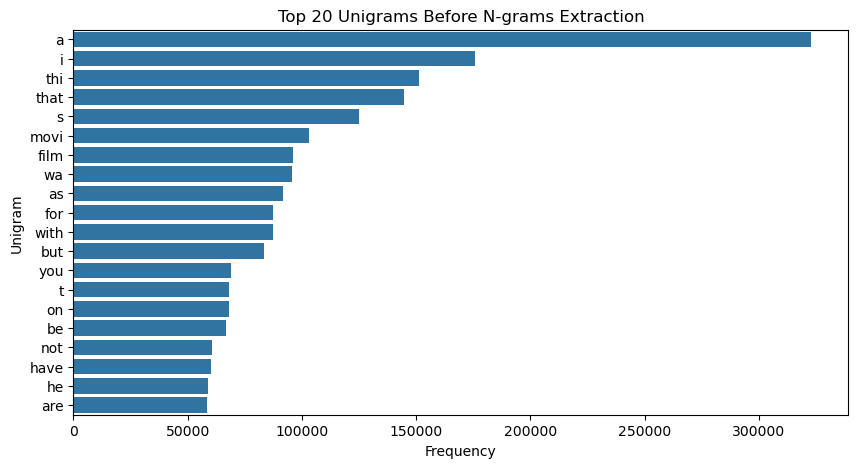

N-grams shape: (50000, 2541316)


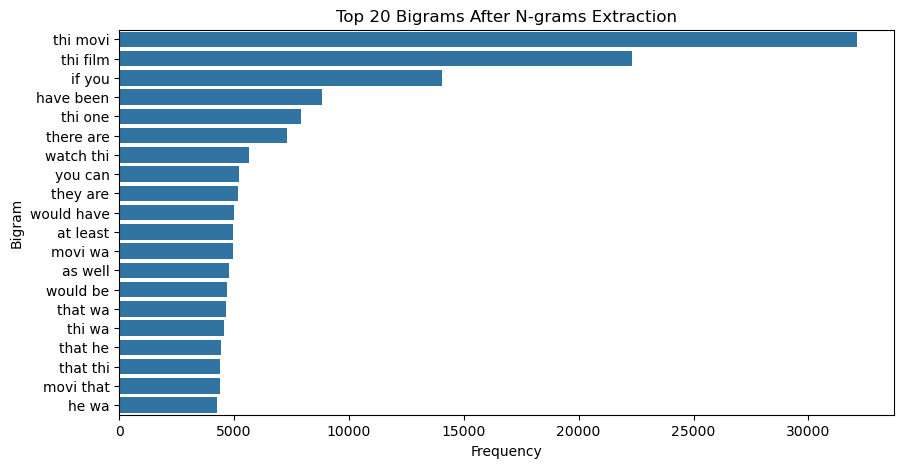

Saved to: ngrams_extracted.csv


In [1]:
# IT24100068_NgramsExtraction.ipynb
# IT24100068 - N-grams Extraction
# Justification: Unigrams may miss contextual sentiment (e.g., 'not good'). Extracting bigrams captures phrases that better reflect sentiment.
# Technique: Use CountVectorizer to extract unigrams and bigrams.

# Import libraries
import nltk
import pandas as pd
import numpy as np  # Added for array operations
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Download NLTK resources
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# Load data from previous step
df = pd.read_csv('../results/outputs/stemmed.csv')
print("Loaded shape:", df.shape)
df.head()

# Before n-grams: Unigram frequency (sample from stemmed text)
unigrams_before = Counter(' '.join(df['review']).split())
common_unigrams = unigrams_before.most_common(20)
before_df = pd.DataFrame(common_unigrams, columns=['Unigram', 'Frequency'])

# EDA Visualization: Bar plot before n-grams
plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Unigram', data=before_df)
plt.title("Top 20 Unigrams Before N-grams Extraction")
plt.show()

# Extract n-grams
vectorizer = CountVectorizer(ngram_range=(1, 2))  # Unigrams and bigrams
X_ngrams = vectorizer.fit_transform(df['review'])
print("N-grams shape:", X_ngrams.shape)

# Save vocabulary and text for next step
pd.DataFrame(vectorizer.vocabulary_.items(), columns=['ngram', 'index']).to_csv('../results/outputs/ngrams_vocab.csv', index=False)
df['review_ngrams'] = df['review']  # Placeholder for compatibility
df.to_csv('../results/outputs/ngrams_extracted.csv', index=False)

# After n-grams: Bigram frequency (fixed to avoid .toarray())
ngram_vocab = pd.read_csv('../results/outputs/ngrams_vocab.csv')

# Get mask for bigrams (words with a space)
bigram_mask = ngram_vocab['ngram'].str.contains(' ', na=False)
bigram_indices = ngram_vocab[bigram_mask]['index'].to_list()

# Sum frequencies directly from sparse matrix
bigram_freq = np.array(X_ngrams[:, bigram_indices].sum(axis=0)).ravel()

# Pick top 20 bigrams
top_indices = np.argsort(bigram_freq)[::-1][:20]
top_bigrams = ngram_vocab[bigram_mask].iloc[top_indices].reset_index(drop=True)
top_frequencies = bigram_freq[top_indices]

# Create DataFrame
after_df = pd.DataFrame({
    'Bigram': top_bigrams['ngram'],
    'Frequency': top_frequencies
})

# EDA Visualization: Bar plot after n-grams
plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Bigram', data=after_df)
plt.title("Top 20 Bigrams After N-grams Extraction")
plt.show()

print("Saved to: ngrams_extracted.csv")
